In [2]:
import numpy as np
import pandas as pd
import random

random.seed(42)
np.random.seed(42)

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

In [3]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)
print(X.shape)
print(y.shape)
print("Column names:", X.columns.tolist())
print("Target names:", data.target_names)
print("Target value counts: \n",y.value_counts())
print("First 5 rows of X:")
print(X.head())
print(y.head())

print("Missing values in X:", X.isnull().sum().sum()) # Check for missing values in the dataset

(569, 30)
(569,)
Column names: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']
Target names: ['malignant' 'benign']
Target value counts: 
 1    357
0    212
Name: count, dtype: int64
First 5 rows of X:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.

### Minimal data preparation

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)
print("Training set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)


Training set shape: (455, 30) (455,)
Test set shape: (114, 30) (114,)


### Baseline models

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [6]:
logistic_regression_model = LogisticRegression(max_iter=5000, random_state=42)
random_forest_model = RandomForestClassifier(random_state=42)
xgboost_model = XGBClassifier(random_state=42, eval_metric="logloss")
catboost_model = CatBoostClassifier(random_state=42, verbose=0)

In [7]:
logistic_regression_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)
xgboost_model.fit(X_train, y_train)
catboost_model.fit(X_train, y_train)

CatBoostClassifier(random_state=42, verbose=0)

### Prediction

In [8]:
logistic_regression_predictions = logistic_regression_model.predict(X_test)
random_forest_predictions = random_forest_model.predict(X_test)
xgboost_predictions = xgboost_model.predict(X_test)
catboost_predictions = catboost_model.predict(X_test)

In [9]:
logistic_regression_probabilities = logistic_regression_model.predict_proba(X_test)[:, 1]
random_forest_probabilities = random_forest_model.predict_proba(X_test)[:, 1]
xgboost_probabilities = xgboost_model.predict_proba(X_test)[:, 1]
catboost_probabilities = catboost_model.predict_proba(X_test)[:, 1]

### Score metrics

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [11]:
logistic_regression_accuracy = accuracy_score(y_test, logistic_regression_predictions)
logistic_regression_precision = precision_score(y_test, logistic_regression_predictions)
logistic_regression_recall = recall_score(y_test, logistic_regression_predictions)
logistic_regression_f1 = f1_score(y_test, logistic_regression_predictions)
logistic_regression_roc_auc = roc_auc_score(y_test, logistic_regression_probabilities)

random_forest_accuracy = accuracy_score(y_test, random_forest_predictions)
random_forest_precision = precision_score(y_test, random_forest_predictions)
random_forest_recall = recall_score(y_test, random_forest_predictions)
random_forest_f1 = f1_score(y_test, random_forest_predictions)
random_forest_roc_auc = roc_auc_score(y_test, random_forest_probabilities)

xgboost_accuracy = accuracy_score(y_test, xgboost_predictions)
xgboost_precision = precision_score(y_test, xgboost_predictions)
xgboost_recall = recall_score(y_test, xgboost_predictions)
xgboost_f1 = f1_score(y_test, xgboost_predictions)
xgboost_roc_auc = roc_auc_score(y_test, xgboost_probabilities)

catboost_accuracy = accuracy_score(y_test, catboost_predictions)
catboost_precision = precision_score(y_test, catboost_predictions)
catboost_recall = recall_score(y_test, catboost_predictions)
catboost_f1 = f1_score(y_test, catboost_predictions)
catboost_roc_auc = roc_auc_score(y_test, catboost_probabilities)

print("Logistic Regression metrics:")
print("Accuracy:", logistic_regression_accuracy)
print("Precision:", logistic_regression_precision)
print("Recall:", logistic_regression_recall)
print("F1-score:", logistic_regression_f1)
print("ROC-AUC:", logistic_regression_roc_auc)
print()

print("Random Forest metrics:")
print("Accuracy:", random_forest_accuracy)
print("Precision:", random_forest_precision)
print("Recall:", random_forest_recall)
print("F1-score:", random_forest_f1)
print("ROC-AUC:", random_forest_roc_auc)
print()

print("XGBoost metrics:")
print("Accuracy:", xgboost_accuracy)
print("Precision:", xgboost_precision)
print("Recall:", xgboost_recall)
print("F1-score:", xgboost_f1)
print("ROC-AUC:", xgboost_roc_auc)
print()

print("CatBoost metrics:")
print("Accuracy:", catboost_accuracy)
print("Precision:", catboost_precision)
print("Recall:", catboost_recall)
print("F1-score:", catboost_f1)
print("ROC-AUC:", catboost_roc_auc)



Logistic Regression metrics:
Accuracy: 0.9649122807017544
Precision: 0.9594594594594594
Recall: 0.9861111111111112
F1-score: 0.9726027397260274
ROC-AUC: 0.9953703703703703

Random Forest metrics:
Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1-score: 0.9655172413793104
ROC-AUC: 0.9937169312169312

XGBoost metrics:
Accuracy: 0.956140350877193
Precision: 0.9466666666666667
Recall: 0.9861111111111112
F1-score: 0.9659863945578231
ROC-AUC: 0.9900793650793651

CatBoost metrics:
Accuracy: 0.956140350877193
Precision: 0.9466666666666667
Recall: 0.9861111111111112
F1-score: 0.9659863945578231
ROC-AUC: 0.9950396825396826


In [12]:
results_df = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest", "XGBoost", "CatBoost"],
    "accuracy": [
        logistic_regression_accuracy,
        random_forest_accuracy,
        xgboost_accuracy,
        catboost_accuracy
    ],
    "precision": [
        logistic_regression_precision,
        random_forest_precision,
        xgboost_precision,
        catboost_precision
    ],
    "recall": [
        logistic_regression_recall,
        random_forest_recall,
        xgboost_recall,
        catboost_recall
    ],
    "f1_score": [
        logistic_regression_f1,
        random_forest_f1,
        xgboost_f1,
        catboost_f1
    ],
    "roc_auc": [
        logistic_regression_roc_auc,
        random_forest_roc_auc,
        xgboost_roc_auc,
        catboost_roc_auc
    ]
})

results_df

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.964912,0.959459,0.986111,0.972603,0.995370
1,Random Forest,0.956140,0.958904,0.972222,0.965517,0.993717
2,XGBoost,0.956140,0.946667,0.986111,0.965986,0.990079
3,CatBoost,0.956140,0.946667,0.986111,0.965986,0.995040


In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

[[39  3]
 [ 1 71]]


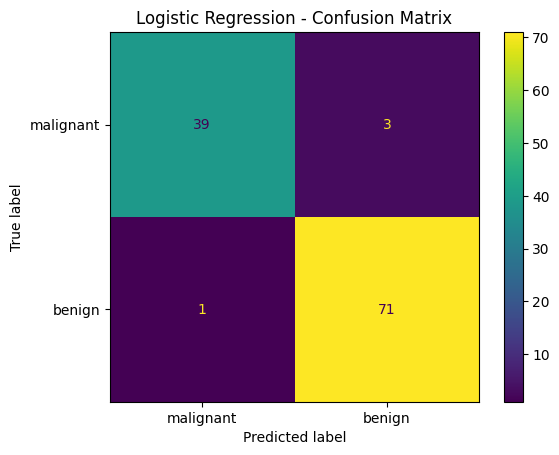

              precision    recall  f1-score   support

   malignant       0.97      0.93      0.95        42
      benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [16]:
logistic_regression_confusion_matrix = confusion_matrix(y_test, logistic_regression_predictions)
print(logistic_regression_confusion_matrix)

logistic_regression_display = ConfusionMatrixDisplay(
    confusion_matrix=logistic_regression_confusion_matrix,
    display_labels=data.target_names
)

logistic_regression_display.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()
print(classification_report(y_test, logistic_regression_predictions, target_names=data.target_names))

In [18]:
models_predictions = {
    "Logistic Regression": logistic_regression_predictions,
    "Random Forest": random_forest_predictions,
    "XGBoost": xgboost_predictions,
    "CatBoost": catboost_predictions
}

for model_name, predictions in models_predictions.items():
    print(f"{model_name}")
    
    model_confusion_matrix = confusion_matrix(y_test, predictions)
    print("Confusion Matrix:")
    print(model_confusion_matrix)
    print()
    
    print("Classification Report:")
    print(classification_report(y_test, predictions, target_names=data.target_names))
    print("-" * 50)
    print()

Logistic Regression
Confusion Matrix:
[[39  3]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.97      0.93      0.95        42
      benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

--------------------------------------------------

Random Forest
Confusion Matrix:
[[39  3]
 [ 2 70]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

--------------------------------------------------

XGBoost
Confusion Matrix:
[[38  4]
 [ 1 71]]

Classification Report:
              pre

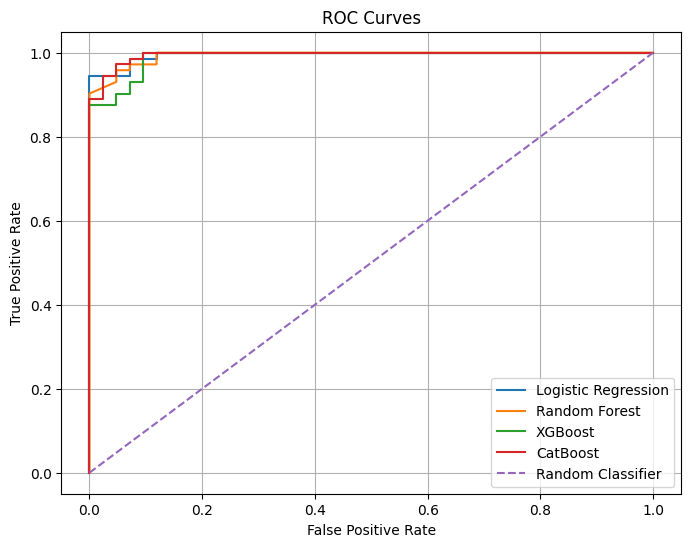

In [20]:
from sklearn.metrics import roc_curve
models_probabilities = {
    "Logistic Regression": logistic_regression_probabilities,
    "Random Forest": random_forest_probabilities,
    "XGBoost": xgboost_probabilities,
    "CatBoost": catboost_probabilities
}

plt.figure(figsize=(8, 6))

for model_name, probabilities in models_probabilities.items():
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, probabilities)
    plt.plot(false_positive_rate, true_positive_rate, label=model_name)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
results_df.to_csv("results_baseline_models.csv", index=False)

In [ ]:
baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss"),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0)
}

baseline_results = []

for model_name, model in baseline_models.items():
    print(f"Training and evaluating: {model_name}")
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    roc_auc = roc_auc_score(y_test, probabilities)

    baseline_results.append({
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc
    })

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df = baseline_results_df.sort_values(by="roc_auc", ascending=False)
baseline_results_df
baseline_results_df.to_csv("baseline_results_automated.csv", index=False)
